### Averaging out replicates

In [1]:
import os
import re
import pandas as pd
from tqdm import tqdm  # Import tqdm for progress bars

def extract_base(col_name):
    """
    Extracts the base condition name from a column name by removing a replicate marker.
    Recognizes patterns like:
      - rep1, rep 1, rep_1, replicate 1, replicate_1, Replicate, etc.
    even when followed by extra text.
    """
    pattern = re.compile(r"^(.*?)\s*(rep(?:licate)?\s*[_-]?\s*\d+)(.*)$", re.IGNORECASE)
    m = pattern.match(col_name)
    if m:
        # Concatenate the part before the replicate marker with the part after it.
        base = (m.group(1) + m.group(3)).strip()
        if base:
            return base
    return col_name

def format_float(x):
    """Format floats with 6 significant digits; otherwise return the value unchanged."""
    if isinstance(x, float):
        return format(x, ".6g")
    return x

# List of annotation row identifiers to exclude from averaging.
annotation_keys = ['EWEIGHT', 'NAME', 'GWEIGHT']

# Define the root directory containing the subfolders with .pcl files.
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted"

# List all subfolders in the root directory.
subfolders = [sub for sub in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, sub))]

# Iterate over each subfolder with a progress bar.
for subfolder in tqdm(subfolders, desc="Processing subfolders"):
    subfolder_path = os.path.join(root_dir, subfolder)
    # List all files ending with .pcl in the current subfolder.
    pcl_files = [file_name for file_name in os.listdir(subfolder_path) if file_name.endswith(".pcl")]
    
    for file_name in pcl_files:
        file_path = os.path.join(subfolder_path, file_name)
        try:
            # Read the file into a DataFrame (assuming tab-delimited and the first column is the index)
            df = pd.read_csv(file_path, sep="\t", index_col=0)

            # Separate annotation rows from the data rows.
            annotations = df.loc[df.index.isin(annotation_keys)]
            data = df.loc[~df.index.isin(annotation_keys)]

            # Build a dictionary grouping columns by their "base" name
            groups = {}
            for col in data.columns:
                base = extract_base(col)
                groups.setdefault(base, []).append(col)

            # Identify if any averaging is needed
            needs_averaging = any(len(cols) > 1 for cols in groups.values())

            if not needs_averaging:
                # Skip processing if no replicates are present
                continue

            # Create a new DataFrame for the averaged expression data.
            new_data = pd.DataFrame(index=data.index)
            for base, cols in groups.items():
                if len(cols) > 1:
                    new_data[base] = data[cols].mean(axis=1)
                else:
                    new_data[base] = data[cols[0]]

            # Combine the annotations with the averaged data.
            new_df = pd.concat([annotations, new_data])

            # Format all float values to 6 significant digits.
            new_df = new_df.applymap(format_float)

            # Overwrite the original file with the new DataFrame.
            new_df.to_csv(file_path, sep="\t")

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

print("Processing complete.")

Processing subfolders: 100%|██████████| 309/309 [00:21<00:00, 14.34it/s]

Processing complete.


### Wild Type

In [ ]:
import os
import re
import pandas as pd

# Define the root directory
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted"

# Regex pattern to detect 'wt' in various formats
wt_pattern = re.compile(r"(^|[_\W])wt([_\W]|$)", re.IGNORECASE)

# List to store matching file paths
matching_files = []

# Walk through all subdirectories and files
for subdir, _, files in os.walk(root_dir):
    for file_name in files:
        if file_name.endswith(".pcl"):
            file_path = os.path.join(subdir, file_name)
            try:
                # Read the file to inspect column names
                df = pd.read_csv(file_path, sep="\t", index_col=0, nrows=1)  # Read only header
                if any(wt_pattern.search(col) for col in df.columns):
                    matching_files.append(file_path)
                    print(file_path)
                    if len(matching_files) >= 3:
                        break
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    if len(matching_files) >= 3:
        break

/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted/Cocklin_2011_PMID_21196523/GSE8453.final.pcl
/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted/Garcia-Rodriguez_2012_PMID_22493290/GSE29420_final.pcl
/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted/Miller-Fleming_2014_PMID_24706893/GSE56124.remapped.final.pcl
['/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted/Cocklin_2011_PMID_21196523/GSE8453.final.pcl', '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted/Garcia-Rodriguez_2012_PMID_22493290/GSE29420_final.pcl', '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted/Miller-Fleming_2014_PMID_24706893/GSE56124.remapped.final.pcl']


In [ ]:
import os
import re
import pandas as pd


# Define the root directory for the single channel .pcl files.
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted"

# Regex pattern to detect 'wt' in various forms (e.g., "wt", "_wt_", "somethingwt", "wtSomething", etc.)
wt_pattern = re.compile(r"(^|[_\W])wt([_\W]|$)", re.IGNORECASE)

# A list to hold DataFrames with WT columns from each file.
df_list = []

# Walk through all subdirectories and files under the root.
for subdir, _, files in os.walk(root_dir):
    for file_name in files:
        if file_name.endswith(".pcl"):
            file_path = os.path.join(subdir, file_name)
            try:
                # Read the .pcl file, assuming tab-delimited and first column is index.
                df = pd.read_csv(file_path, sep="\t", index_col=0)
                # Ensure the index is unique by dropping duplicate gene names
                df = df[~df.index.duplicated(keep='first')]
                # Identify WT columns based on column names matching the regex.
                wt_cols = [col for col in df.columns if wt_pattern.search(col)]
                if wt_cols:
                    # Select only the WT columns.
                    df_wt = df[wt_cols].copy()
                    # Rename columns to include the source file identifier (e.g. file base name) for later grouping.
                    file_id = os.path.splitext(file_name)[0]
                    df_wt.columns = [f"{file_id}:{col}" for col in df_wt.columns]
                    # Append the DataFrame to our list.
                    df_list.append(df_wt)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Check if we have found any WT columns.
if not df_list:
    print("No WT columns found in any files.")
else:
    # Concatenate all WT DataFrames along columns using an outer join so that every gene (row) is present.
    all_wt_df = pd.concat(df_list, axis=1, join="outer")
    
    # Optionally, you might want to sort columns by file grouping:
    sorted_cols = sorted(all_wt_df.columns, key=lambda x: x.split(":")[0])
    all_wt_df = all_wt_df[sorted_cols]
    
    # Compute the correlation matrix (pairwise correlations; pandas handles NaNs pairwise).
    corr_matrix = all_wt_df.corr()

    # plt.figure(figsize=(12, 10))
    # sns.heatmap(corr_matrix, cmap="vlag", center=0, square=True, linewidths=0.5)
    # plt.title("WT Columns Correlation Matrix")
    # plt.show()

    print("Correlation matrix computed successfully.")

Correlation matrix computed successfully.


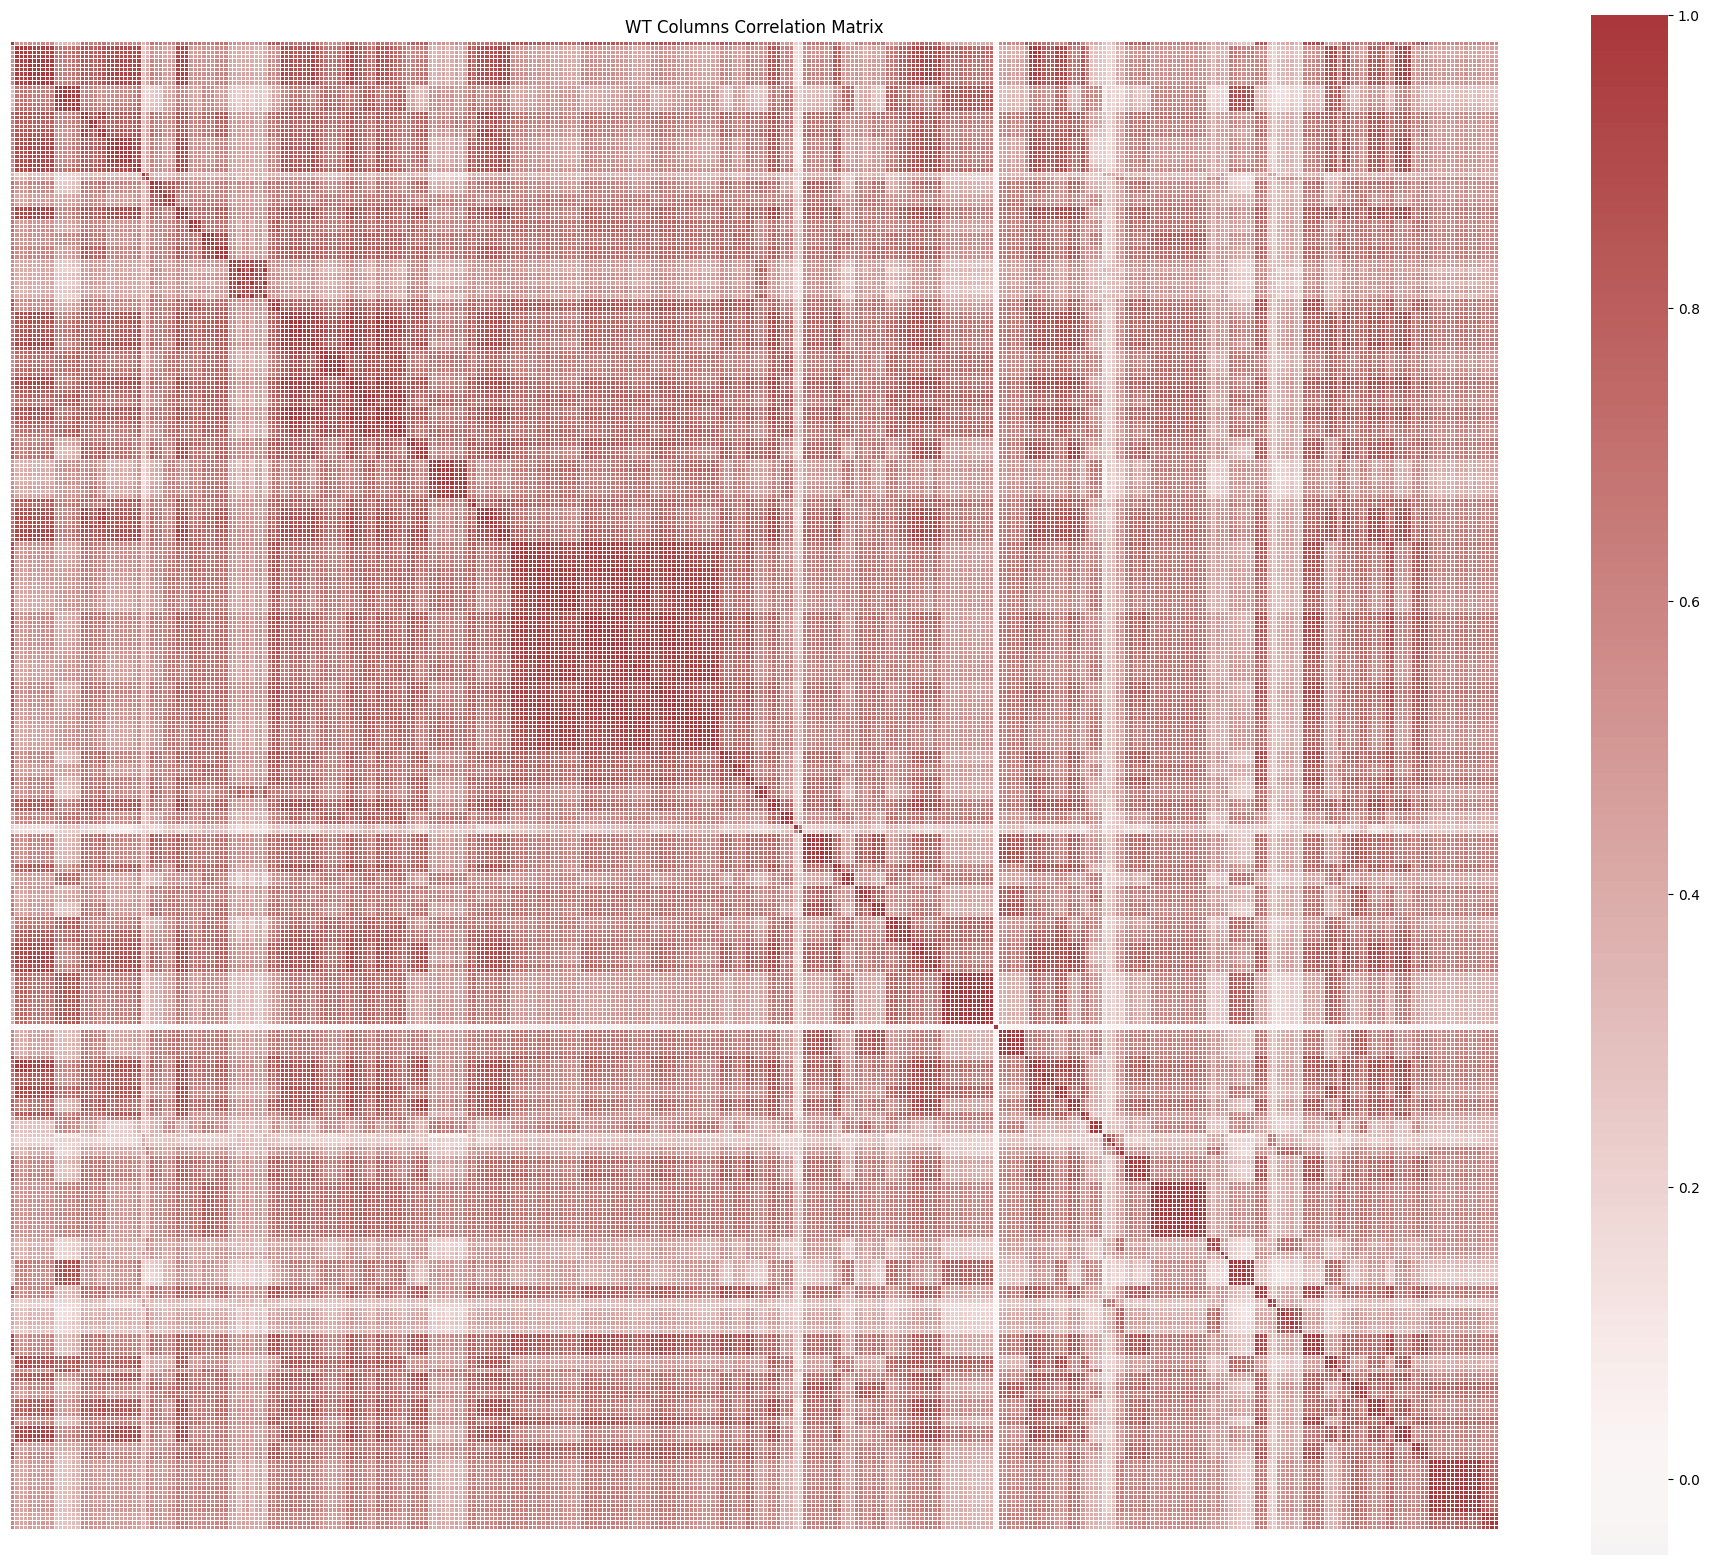

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 20))
ax = sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=False,  # Hide x-axis tick labels
    yticklabels=False   # Hide y-axis tick labels
)
plt.title("WT Columns Correlation Matrix")
plt.show()

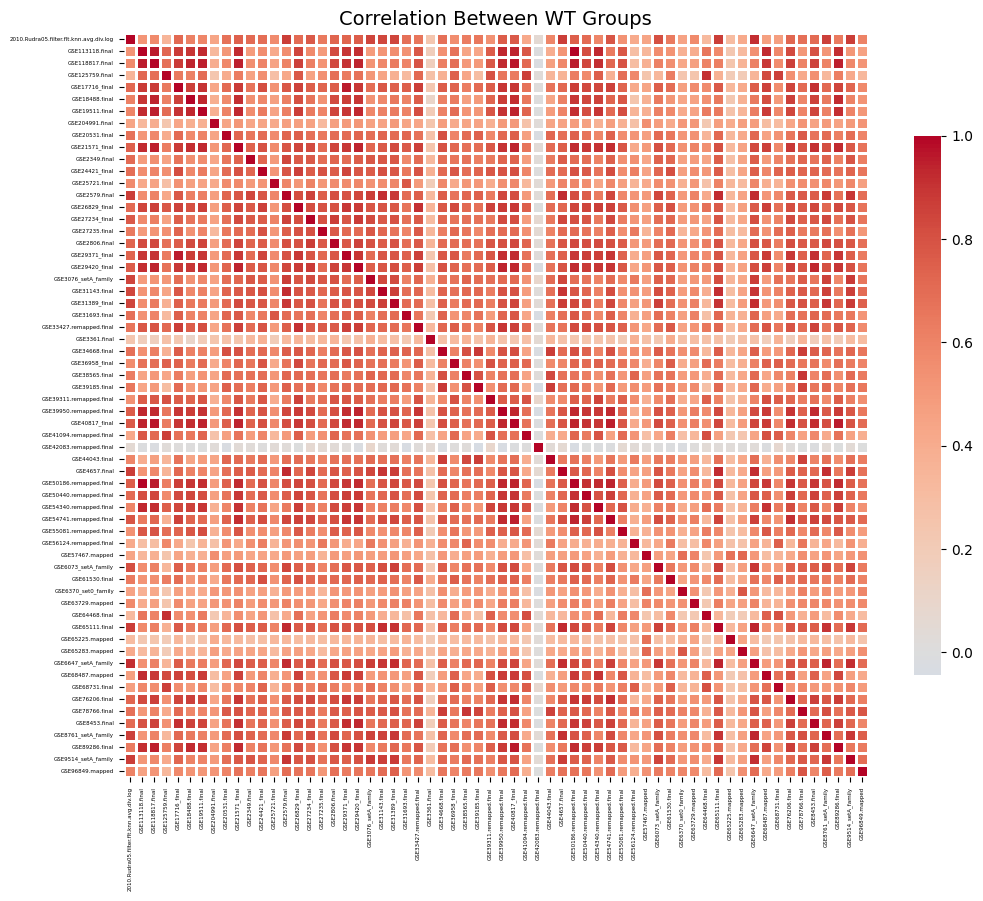

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group WT columns by file name (each group represents a different .pcl file)
grouped_wt_df = all_wt_df.T.groupby(lambda x: x.split(":")[0]).mean().T  # Compute mean WT per group

# Step 2: Compute correlation matrix between WT groups
group_corr_matrix = grouped_wt_df.corr().fillna(0)  # Fill NaN values with 0 for better visualization

sorted_indices = sorted(group_corr_matrix.index)
group_corr_matrix = group_corr_matrix.loc[sorted_indices, sorted_indices]

# Step 3: Plot the correlation heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    group_corr_matrix,
    cmap="coolwarm",  # Better contrast for correlation values
    center=0,
    square=True,
    linewidths=1.0,  # Make grid lines more visible
    annot=False,  # Remove numerical values
    cbar_kws={"shrink": 0.7},  # Adjust color bar size
)

import numpy as np

# Set tick positions at the center of each square
tick_positions = np.arange(len(group_corr_matrix)) + 0.5  

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

ax.set_xticklabels(group_corr_matrix.index, fontsize=4, rotation=90)
ax.set_yticklabels(group_corr_matrix.index, fontsize=4, rotation=0)

plt.title("Correlation Between WT Groups", fontsize=14)
plt.show()


In [21]:
print(len(grouped_wt_df.columns.tolist()))

62
